<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


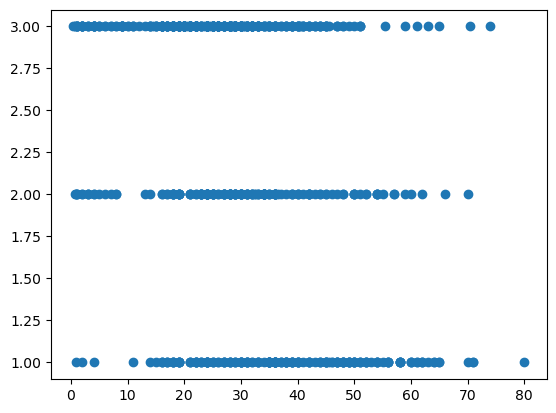

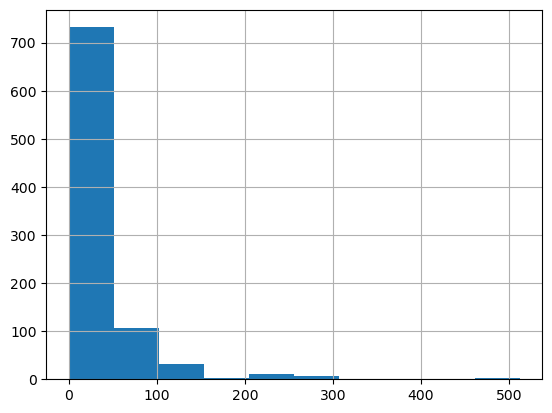

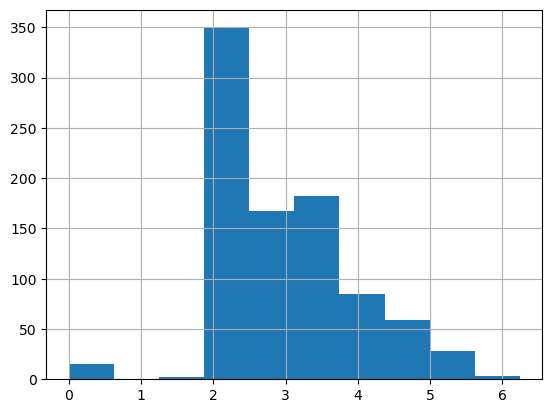

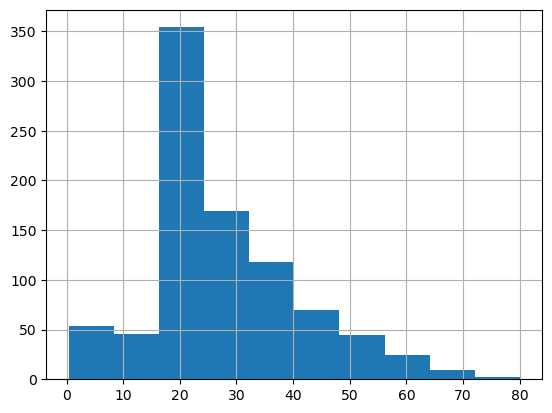

In [2]:
%run ./workbook.ipynb

In [3]:
import torch

X_tensor = torch.tensor(X.values, dtype=torch.float32)
X_tensor.shape

torch.Size([891, 12])

In [ ]:


# view(-1, 1) reshapes a tensor into a 2‑D column vector with one column 
# and as many rows as needed. -1 tells PyTorch to infer that dimension size.
y_tensor = torch.tensor(y.values, dtype=torch.float32).view(-1,1)

import torch.nn as nn


# X_tensor.shape[1] = N → number of input features.

# Input → Dense layer
#
# Takes N input features
# Produces 16 neurons
# y = W*x + b
# W → weight matrix (16 × N)
# b → bias (16)
# nn.Linear(X_tensor.shape[1], 16)

model = nn.Sequential(
    nn.Linear(X_tensor.shape[1], 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
)

# Binary Cross Entropy loss:

# Loss=−[ylog⁡(p)+(1−y)log⁡(1−p)]
# y = true label
# p = predicted probability
# criterion = nn.BCELoss()
# more stable then above
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.008)

for epoch in range(40000):
    pred = model(X_tensor)
    # error
    loss = criterion(pred, y_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 1000 == 0:
        print(epoch, loss.item())


# check final params
# for name, param in model.named_parameters():
#     print(name, param.data)

torch.save(model.state_dict(), Path(current_session).parent / "model.pth")


0 0.7267659902572632
1000 0.29027238488197327
2000 0.24775730073451996
3000 0.22051116824150085
4000 0.20398209989070892
5000 0.19190293550491333
6000 0.18841716647148132
7000 0.17136862874031067
8000 0.15737345814704895
9000 0.1487724930047989
10000 0.1336677521467209
11000 0.1597265899181366
12000 0.12754252552986145
13000 0.12256012111902237
14000 0.1710456758737564
15000 0.1348978877067566
16000 0.12341189384460449


In [ ]:
model.load_state_dict(torch.load(Path(current_session).parent / "model.pth"))

with torch.no_grad():
    logits = model(X_test_tensor)
    preds = torch.sigmoid(logits)

pred_labels = (preds > 0.5).squeeze(-1).to(torch.int64).tolist()

# accuracy = (pred_labels == y_test_tensor).float().mean()

# print("Accuracy:", accuracy.item())

res = pd.DataFrame(columns=['PassengerId','Survived'], data=zip(list(p_id) , pred_labels))
res.to_csv(Path(__file__).parent / 'result.csv', encoding='utf-8', index=False)